# Fig 4: TBT Heat Map (Batch Size × Context Length)

**Output:** `model_outputs/<MODEL_SHORT>/paper/section3/fig4/decode_grid_heatmap.{pdf,png}`

Paths are resolved via `MODEL_DATA_DIR` from `profiling/config.py` (set `MODELS_ROOT` in `config.env` to override).

### Call order
1. `profiling/launch_decode_grid.sh` — collect decode-grid data (4 GPUs, ~2 h; writes to `model_outputs/<MODEL_SHORT>/paper/section3/profiling/decode_grid_data/`)
2. `scripts/plot_decode_grid.py`

Step 1 only needs to run once. If raw data already exists, skip straight to step 2.

In [1]:
import subprocess
from pathlib import Path

REPO_ROOT = next(
    p for p in [Path.cwd()] + list(Path.cwd().parents)
    if (p / ".conserve_root").exists()
)


def run(cmd):
    buf = []
    with subprocess.Popen(
        cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1
    ) as proc:
        for line in proc.stdout:
            print(line, end="", flush=True)
            buf.append(line)
    if proc.returncode != 0:
        raise RuntimeError(f"Command failed (exit {proc.returncode}): {' '.join(str(c) for c in cmd)}")
    return "".join(buf)


In [2]:
# Config and GPU validation — run before any data-collection cells.
import subprocess, os, sys
sys.path.insert(0, str(REPO_ROOT / "profiling"))
from config import TENSOR_PARALLEL_SIZE, MODEL, MODEL_SHORT, GPU_TYPE

_smi = subprocess.check_output(
    ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"], text=True
).strip().splitlines()
N_GPUS = len(_smi)
GPU_NAMES = _smi

def gpu_range(group_idx):
    # mirrors config.sh:gpu_range()
    tp = TENSOR_PARALLEL_SIZE
    start = group_idx * tp
    if start + tp > N_GPUS:
        raise ValueError(
            f"Group {group_idx} needs GPUs {start}–{start+tp-1}, only {N_GPUS} available"
        )
    return ",".join(str(g) for g in range(start, start + tp))

N_SHARDS = N_GPUS // TENSOR_PARALLEL_SIZE

gpu_hw = GPU_NAMES[0] if GPU_NAMES else "unknown"
print(f"Model:  {MODEL}  ({MODEL_SHORT})")
print(f"GPU:    {gpu_hw}  ×{N_GPUS}  [GPU_TYPE={GPU_TYPE}]")
print(f"TP:     {TENSOR_PARALLEL_SIZE} ({TENSOR_PARALLEL_SIZE} GPU{'s' if TENSOR_PARALLEL_SIZE > 1 else ''}/group)")
print(f"Shards: {N_SHARDS}")
print("Groups: " + "   |   ".join(
    f"{i} → GPUs {gpu_range(i)}" for i in range(N_SHARDS)
))

os.environ["GPUS"] = " ".join(str(i) for i in range(N_SHARDS))
print(f"\nGPUS env → {os.environ['GPUS']!r}")


Model:  Qwen/Qwen3.6-27B  (Qwen3.6-27B)
GPU:    NVIDIA A40  ×4  [GPU_TYPE=A40]
TP:     2 (2 GPUs/group)
Shards: 2
Groups: 0 → GPUs 0,1   |   1 → GPUs 2,3

GPUS env → '0 1'


In [3]:
# Step 1: collect raw decode-grid data. Skip if data already exists.
run(["bash", str(REPO_ROOT / "profiling/launch_decode_grid.sh")])

Output dir: /data/projects/eicchen/conserve_project/conserve/model_outputs/Qwen3.6-27B/paper/section3/profiling/decode_grid_data


Launching 2 shards on GPUs: 0 1

  shard 0 (GPU 0) -> pid 1209263, log /data/projects/eicchen/conserve_project/conserve/model_outputs/Qwen3.6-27B/paper/section3/profiling/decode_grid_data/launcher_gpu0.log
  shard 1 (GPU 1) -> pid 1209264, log /data/projects/eicchen/conserve_project/conserve/model_outputs/Qwen3.6-27B/paper/section3/profiling/decode_grid_data/launcher_gpu1.log

Waiting for shards to finish...


KeyboardInterrupt: 

Total decode steps across all cells: 50904
 cell_idx   B     L   n  lat_p25  lat_p50  lat_p75  lat_p99  lat_mean  lat_std  kv_per_req_mean  active_kv_mean
        0   1   128 504 12.43575  12.4650 12.50100 12.70570 12.577107 2.280554            159.0           159.0
        1   1   256 504 13.03575  13.1670 13.26000 13.88019 13.211437 2.203747            287.0           287.0
        2   1   512 504 12.42400  12.5185 13.19225 13.42385 12.884905 2.225575            543.0           543.0
        3   1  1024 504 12.75400  13.6440 13.76125 13.94300 13.443810 2.351775           1055.0          1055.0
        4   1  2048 504 12.40750  13.1340 14.04025 15.45883 13.325101 1.056011           2079.0          2079.0
        5   1  4096 504 12.35700  12.9765 13.25900 15.33977 12.947373 0.705232           4127.0          4127.0
        6   1  8192 504 13.20400  14.2135 14.70675 15.56973 14.065730 0.867482           8223.0          8223.0
        7   1 16384 504 12.58600  12.7095 13.45425 14.19885 1

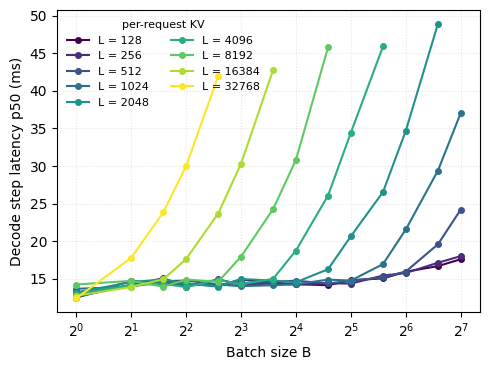

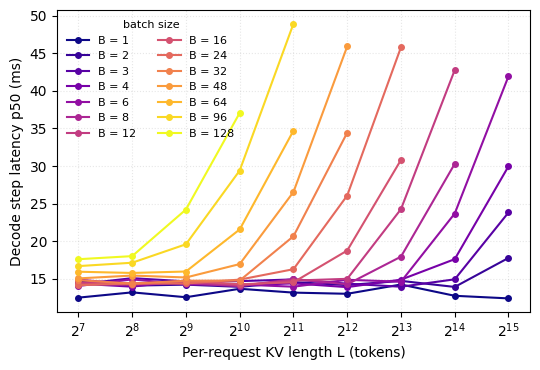

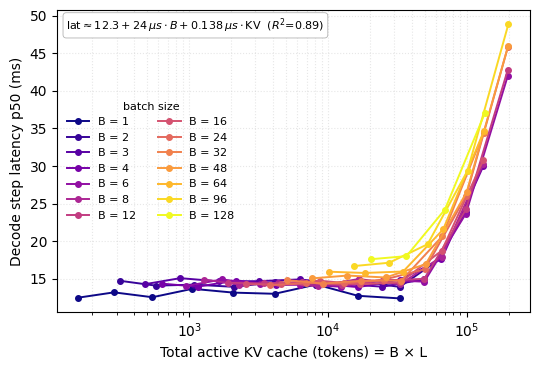

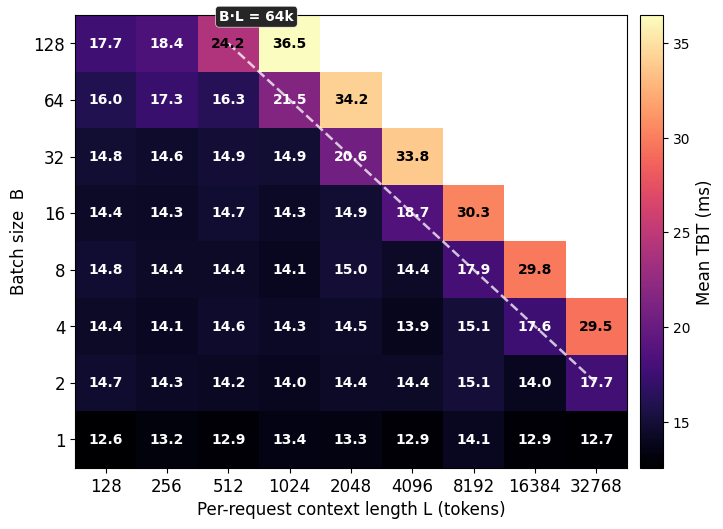

<Figure size 640x480 with 0 Axes>

In [3]:
# Step 2: plot
%matplotlib inline
%run ../scripts/plot_decode_grid.py

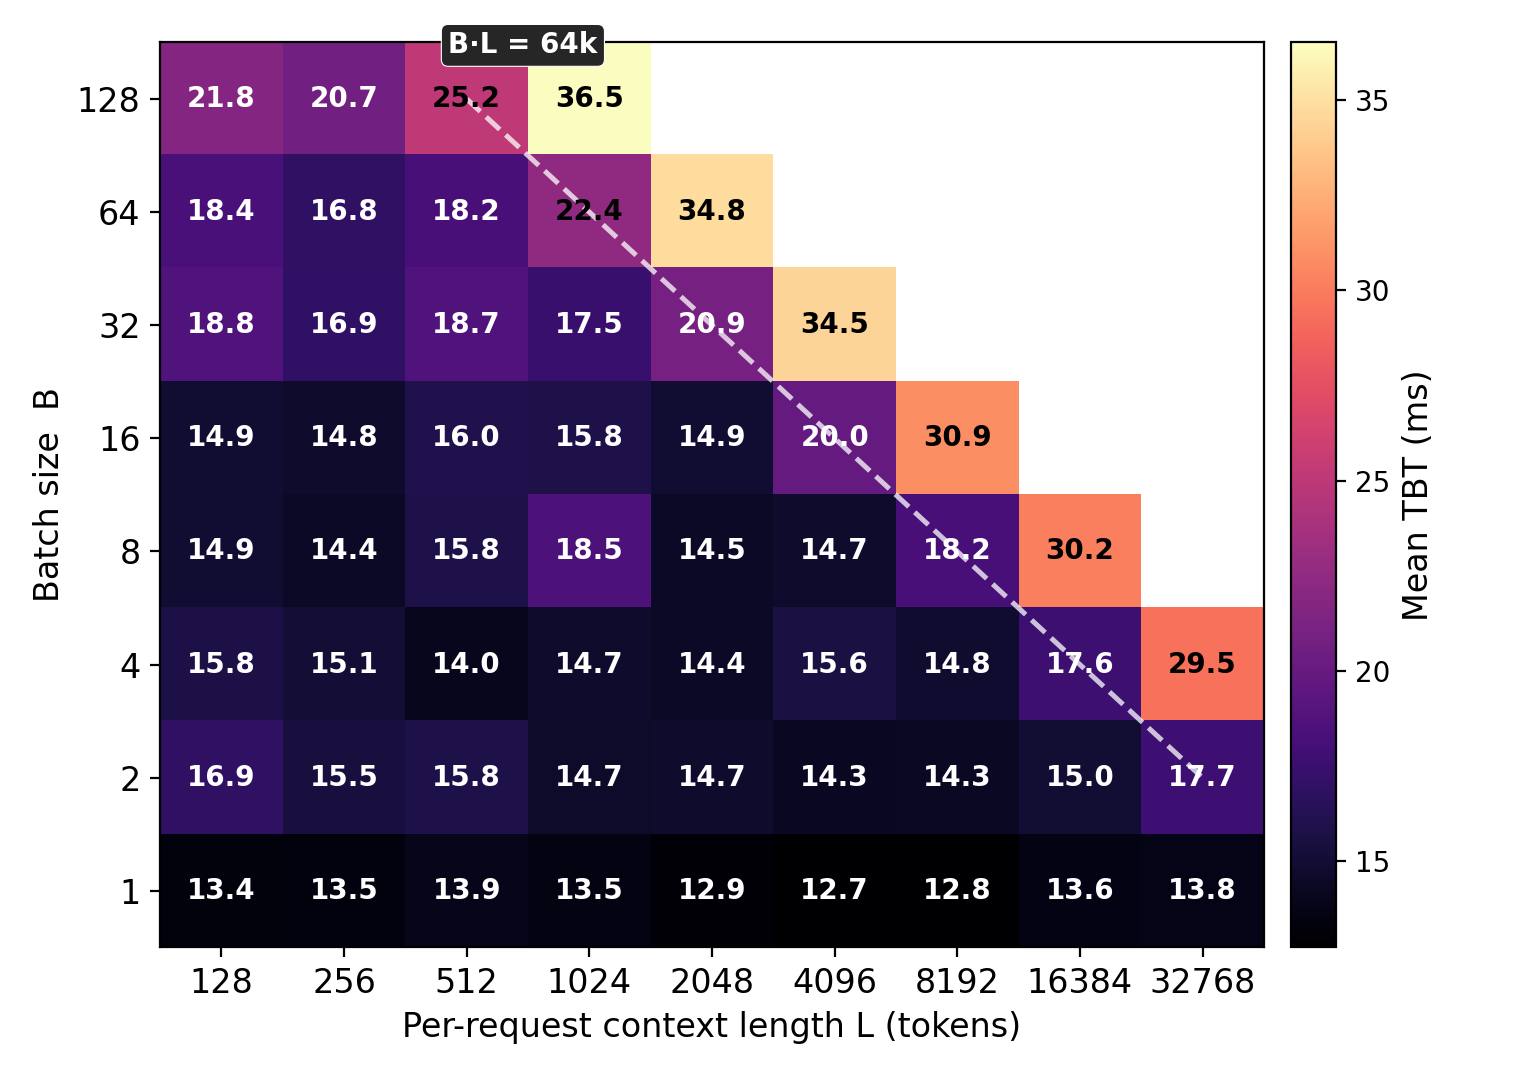

In [4]:
from IPython.display import Image
import sys; sys.path.insert(0, str(REPO_ROOT / "profiling"))
from config import MODEL_SHORT

Image(str(REPO_ROOT / "paper/figures/section3/output" / MODEL_SHORT / "300W" / "decode_grid_heatmap.png"))